In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
print("Eager execution enabled:", tf.executing_eagerly())
import random

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

import datetime
from ..check_stationarity import load_train_data

from scipy.stats import boxcox

Eager execution enabled: True


ImportError: attempted relative import with no known parent package

In [2]:

# Set the random seed for reproducibility
seed = 256
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# train_md, train_qd = load_train_data()
_, train_data_univariate = load_train_data()["GDPC1"]
train_data_univariate = train_data_univariate["GDPC1"]

# Apply Box-Cox transformation to make the series stationary
train_data_univariate_positive = train_data_univariate + abs(train_data_univariate.min()) + 1  # Ensure all values are positive
train_data_univariate_boxcox, lambda_boxcox = boxcox(train_data_univariate_positive)
train_data_univariate_boxcox = pd.DataFrame(train_data_univariate_boxcox, index=train_data_univariate.index, columns=["GDPC1"])

# Plot the original and transformed series
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(train_data_univariate, label="Original Series")
plt.title("Original Series")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(train_data_univariate_boxcox, label="Box-Cox Transformed Series", color="orange")
plt.title("Box-Cox Transformed Series")
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'load_train_data' is not defined

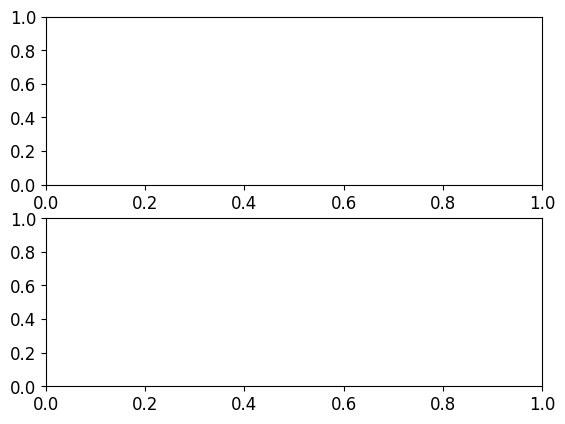

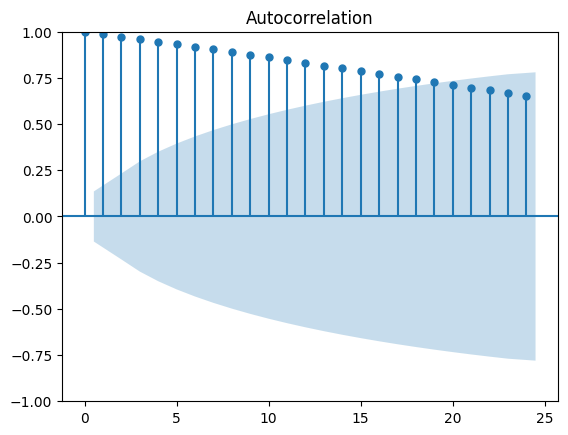

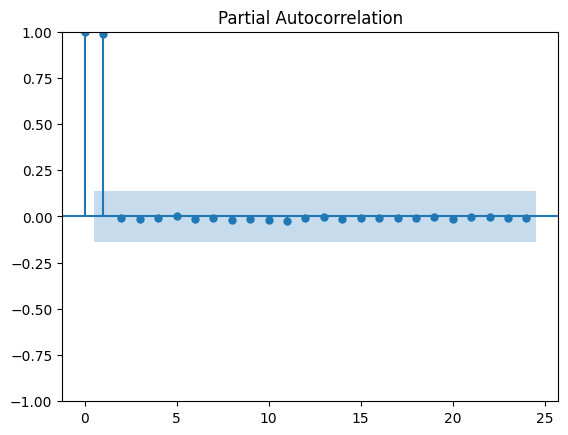

In [ ]:
import matplotlib
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ax1 = plt.subplot(211)
ax2 = plt.subplot(212)

# Plot acf and pacf 
plot_acf(train_data_univariate_boxcox)
plot_pacf(train_data_univariate_boxcox, method="ywm")
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()


The blue regions the points are no longer statistically significant and from the plot we see the last lag that is statistically significant for autocorrelation plot ~2 and partial autocorrelation ~9

In [86]:
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

# Convert train_data_univariate_boxcox to a DataFrame
#train_data_univariate_boxcox = pd.DataFrame(train_data_univariate_boxcox, columns=["GDPC1"])

# Split train and val sets 

train = train_data_univariate_boxcox[:int(len(train_data_univariate_boxcox) * 0.8)]
val = train_data_univariate_boxcox[int(len(train_data_univariate_boxcox) * 0.8):]

# Build ARIMA model and inverse Box-Cox transformation and 1 time difference transformation
model = ARIMA(train, order=(2, 1, 9)).fit()

forecasts = []

# Copy the training data to use for recursive forecasting
history = list(train["GDPC1"])  # Convert to a list for appending new values

# Recursive forecasting
for true_value in val["GDPC1"]:
    # Fit the ARIMA model on the current history
    # model = ARIMA(history, order=(2, 1, 9)).fit()
    
    print("forecast:", model.forecast(steps=1))

    # Forecast the next value
    boxcox_diff_pred = model.forecast(steps=1)[0]
    
    # Inverse Box-Cox transformation
    forecast_value = inv_boxcox(boxcox_diff_pred, lambda_boxcox)
    
    # Append the forecasted value to the forecasts list
    forecasts.append(forecast_value)
    
    model = model.append([true_value], refit=True)
    
    # Append the true value to the history for the next iteration
    history.append(true_value)


# boxcox_diff_pred = model.forecast(len(val))
# # Inverse Box-Cox transformation
# forecast = inv_boxcox(boxcox_diff_pred, lambda_boxcox)




c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-DEC will be used.

c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-DEC will be used.

c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-DEC will be used.

c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



forecast: 2000-12-01    7.058928
Freq: QS-DEC, dtype: float64
forecast: 2001-03-01    7.060449
Freq: QS-DEC, dtype: float64


C:\Users\giada\AppData\Local\Temp\ipykernel_30396\3985816123.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\giada\AppData\Local\Temp\ipykernel_30396\3985816123.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



forecast: 2001-06-01    7.058198
Freq: QS-DEC, dtype: float64
forecast: 2001-09-01    7.059306
Freq: QS-DEC, dtype: float64


C:\Users\giada\AppData\Local\Temp\ipykernel_30396\3985816123.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\giada\AppData\Local\Temp\ipykernel_30396\3985816123.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



...

forecast: 2010-09-01    7.12888
Freq: QS-DEC, dtype: float64


c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\giada\AppData\Local\Temp\ipykernel_30396\3985816123.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



forecast: 2010-12-01    7.131615
Freq: QS-DEC, dtype: float64


c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\giada\AppData\Local\Temp\ipykernel_30396\3985816123.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



forecast: 2011-03-01    7.130481
Freq: QS-DEC, dtype: float64


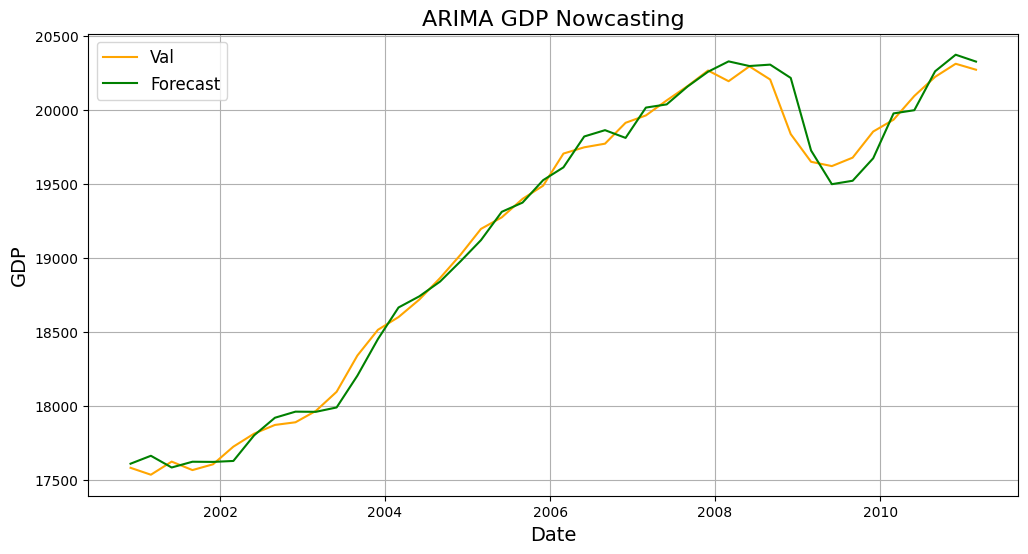

Mean Squared Error: 9403.548227672178


In [87]:
import plotly.graph_objects as go

def plot_forecasts(train: pd.DataFrame, val: pd.DataFrame, forecasts: list, title: str) -> None:
    """
    Function to plot the forecasts for GDP data.
    
    Parameters:
    - train: DataFrame containing the training data with a 'Date' column and 'GDP' column.
    - test: DataFrame containing the test data with a 'Date' column and 'GDP' column.
    - forecasts: List of forecasted values corresponding to the test data.
    - title: Title of the plot.
    """
    plt.figure(figsize=(12, 6))
    
    # Plot training data
    # plt.plot(train.index, inv_boxcox(train['GDPC1'], lambda_boxcox), label='Train', color='blue')
    
    # Plot validation data
    plt.plot(val.index, inv_boxcox(val['GDPC1'], lambda_boxcox), label='Val', color='orange')
    
    # Plot forecast data
    plt.plot(val.index, forecasts, label='Forecast', color='green')
    
    # Add title and labels
    plt.title(title, fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('GDP', fontsize=14)
    
    # Add legend
    plt.legend(fontsize=12)
    
    # Show grid
    plt.grid(True)
    
    # Display the plot
    plt.show()

# Example usage
# Assuming `train`, `test`, and `forecasts` are already defined
# train: DataFrame with 'Date' and 'GDP' columns for training data
# test: DataFrame with 'Date' and 'GDP' columns for test data
# forecasts: List of forecasted GDP values
plot_forecasts(train, val, forecasts, 'ARIMA GDP Nowcasting')
mse = mean_squared_error(inv_boxcox(val['GDPC1'], lambda_boxcox), forecasts)
print("Mean Squared Error:", mse)
